In [1]:
# %matplotlib inline
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
import time
import os

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import statsmodels
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from sklearn.model_selection import StratifiedKFold,KFold
logo = LeaveOneGroupOut()
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import pickle
from bioinfokit import analys, visuz
from scipy import stats

from pimmslearn.sklearn.ae_transformer import AETransformer
from pimmslearn.sklearn.cf_transformer import CollaborativeFilteringTransformer

In [82]:
%run classifiers_functions.ipynb

In [68]:
tmp_train = pd.read_csv("C:/Users/LocalAdmin/Box/Publications/collabs/Erika/OneDrive_1_24-07-2026/POS_ED_Breast Cancer Project_final_2921_features.csv")
Data_train = tmp_train.iloc[:,44:]
Data_train = Data_train.transpose()
Data_train.columns = tmp_train['mz_rt']
# Data_train.to_csv (r'C:/Users/LocalAdmin/Box/Publications/collabs/Erika/OneDrive_1_24-07-2026/Data_raw.csv', index = False, header=True)

In [123]:
Data_n = data_norm((Data_train), method='pqn')
# Data_n_s = data_norm(Data_train_s, method='tic')
Data_log = data_norm(Data_train, method='log')
# Data_log_s = data_norm(Data_n_s, method='log')
Data_log.shape

(198, 2921)

## PIMMS-based data imputation for LC-MS

C:\Users\LocalAdmin\anaconda3\Lib\site-packages\fastprogress\fastprogress.py:74: UserWarning: Your generator is empty.
  warn("Your generator is empty.")


epoch,train_loss,valid_loss,time
0,29834.755859,None,00:00
1,25589.324219,None,00:00
2,23018.603516,None,00:00
3,21405.015625,None,00:00
4,19819.277344,None,00:00
5,18659.666016,None,00:00
6,17663.611328,None,00:00
7,16622.630859,None,00:00
8,15939.198242,None,00:00
9,15410.994141,None,00:00


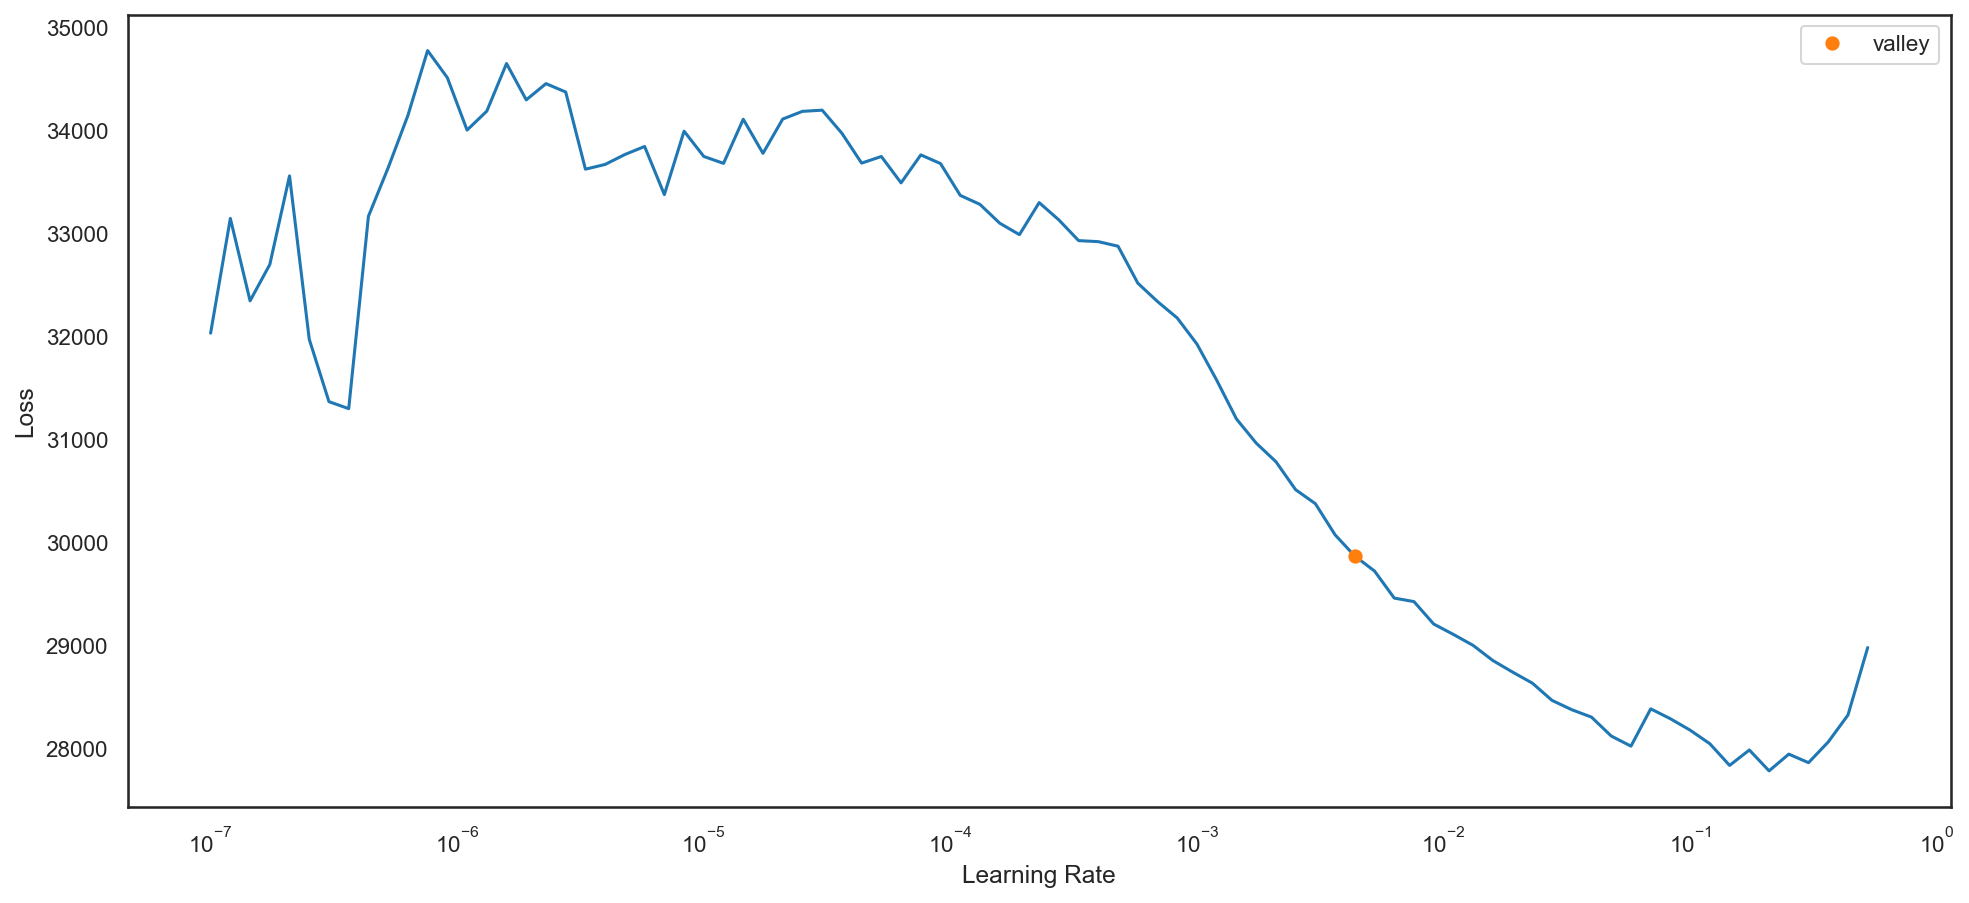

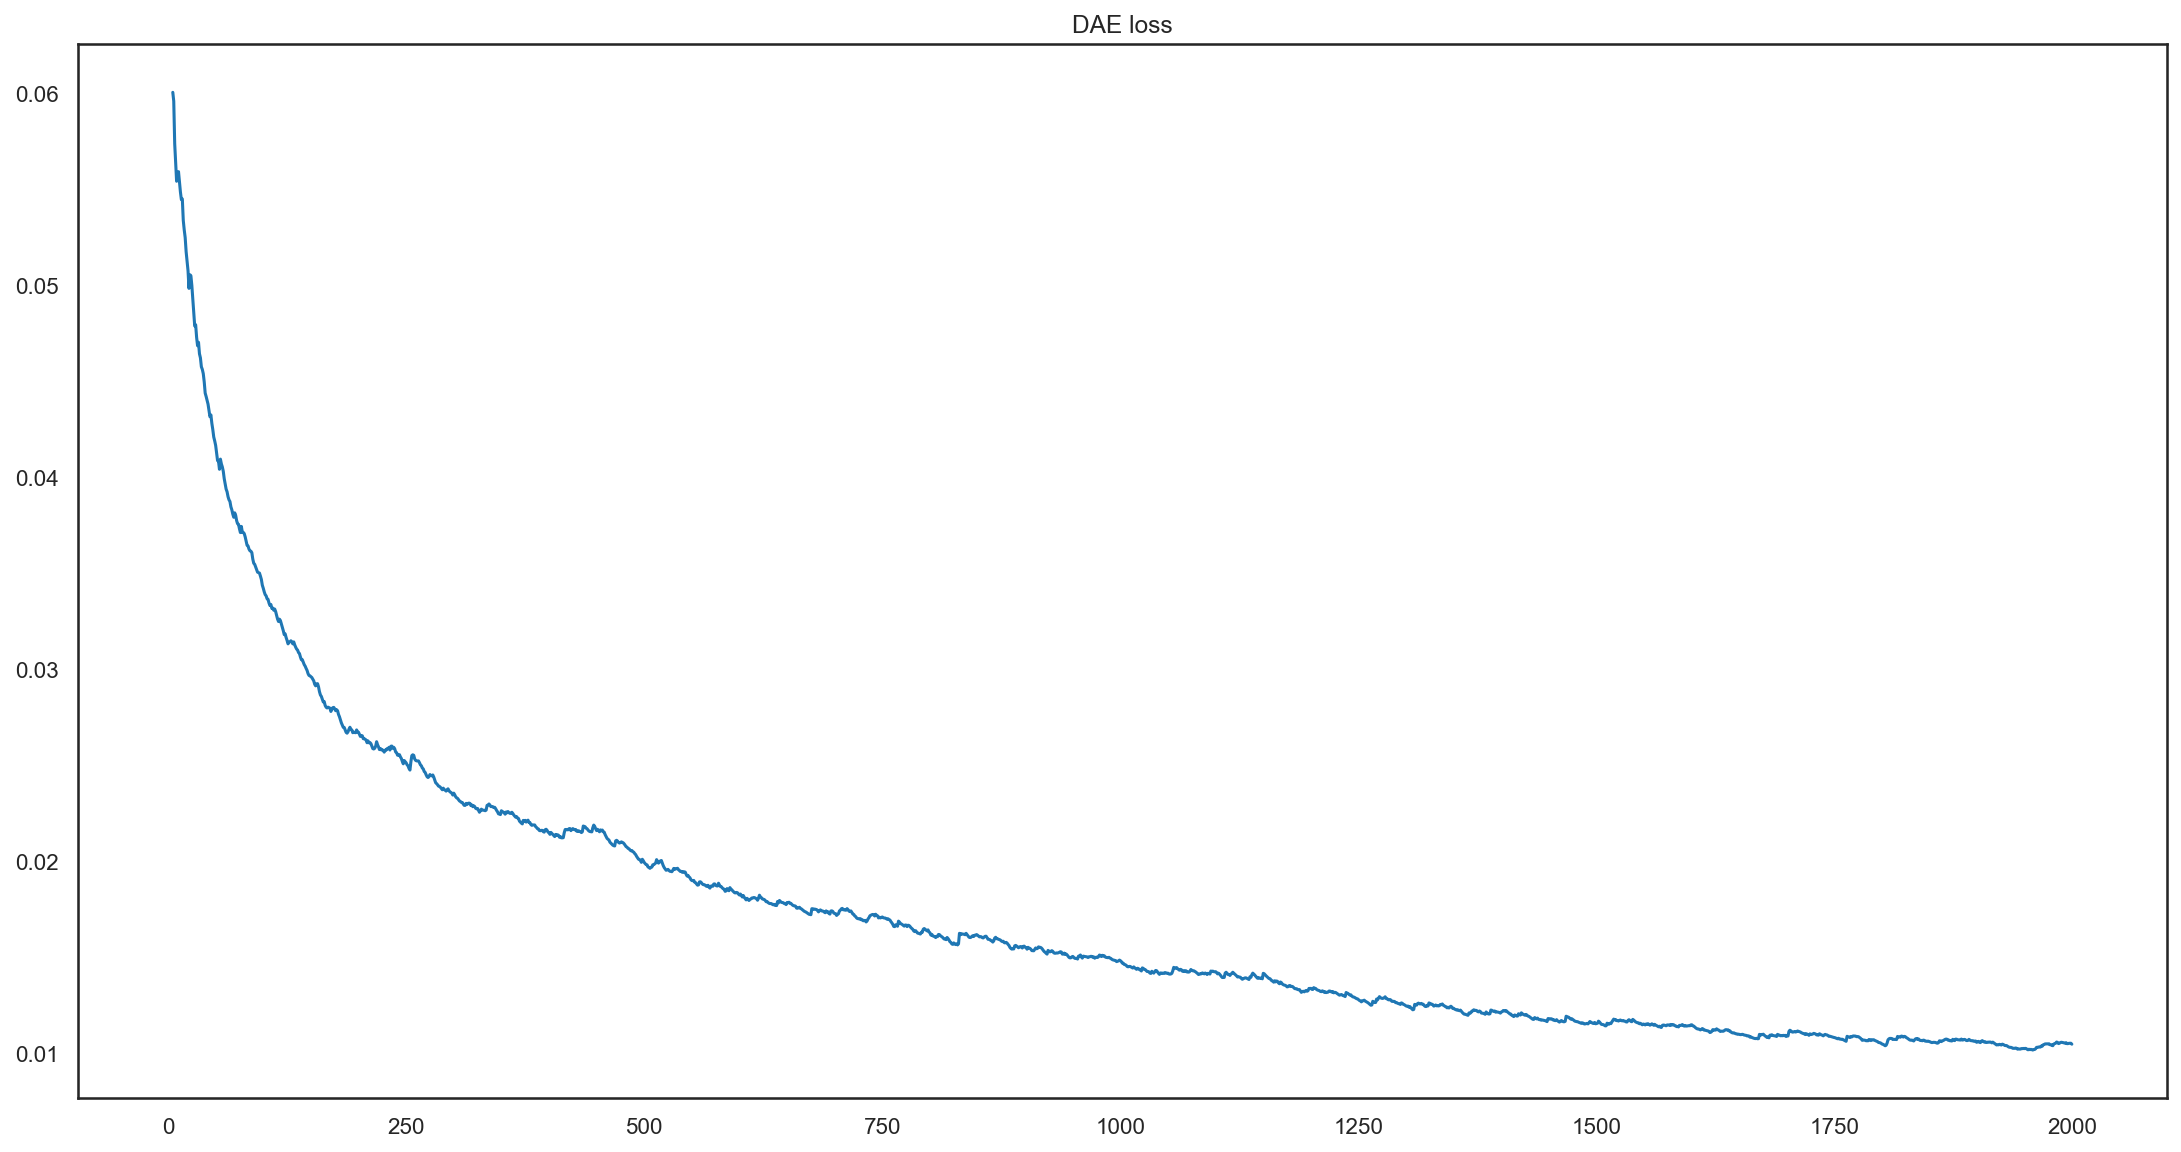

In [88]:
model = AETransformer(
    model='DAE', # or 'VAE'
    hidden_layers=[512,],
    latent_dim=50, # dimension of joint sample and item embedding
    batch_size=10,
)
model.fit(Data_log,
          cuda=False,
          epochs_max=100,
          )
Data_imputed = model.transform(Data_log)
Data_imputed.to_csv (r'C:/Users/LocalAdmin/Box/Publications/collabs/Erika/OneDrive_1_24-07-2026/Data_imputed.csv', index = False, header=True)

In [53]:
metadata = pd.read_csv("C:/Users/LocalAdmin/Box/Publications/collabs/Erika/OneDrive_1_24-07-2026/Metadata_Erika Dorado_Breast Cancer project.csv")
metadata.index = Data_imputed.index
metadata

,Sample,MS name,Type of Sample,Group,Training set,Validation set,HV and Bening Pairs,Simplified Subtype,Simplified type,Grade,Size,Nodes,Age at Diagnosis,Ethnicity
DORADO_LPOS_TOF18_BC_Sample_001_b.mzML,1,DORADO_LPOS_TOF18_BC_Sample_001_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,ILC,2,28,15/22,81,White - British
DORADO_LPOS_TOF18_BC_Sample_002_b.mzML,2,DORADO_LPOS_TOF18_BC_Sample_002_b.mzML,HV,HV,NaN,NaN,pair 1-a,NaN,,NaN,NaN,NaN,30,Other - any other ethnic group
DORADO_LPOS_TOF18_BC_Sample_003_b.mzML,3,DORADO_LPOS_TOF18_BC_Sample_003_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,ILC,2,49 and 25,1 of 1(2.2mm) then 0/9,81,White - British
DORADO_LPOS_TOF18_BC_Sample_004_b.mzML,4,DORADO_LPOS_TOF18_BC_Sample_004_b.mzML,BC pre-op,BC pre-op,NaN,BC pre-op,NaN,ER+ HER2 Neg,ILC,1,Multifocal 50-70mm,LN Neg,57,Black or Black British - Caribbean
DORADO_LPOS_TOF18_BC_Sample_005_b.mzML,5,DORADO_LPOS_TOF18_BC_Sample_005_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,IDC,2,25,0/1,65,White - British
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DORADO_LPOS_TOF18_BC_Sample_202_b.mzML,194,DORADO_LPOS_TOF18_BC_Sample_202_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,IDC,2,36,2/2 positive,46,White - Any other white background
DORADO_LPOS_TOF18_BC_Sample_203_b.mzML,195,DORADO_LPOS_TOF18_BC_Sample_203_b.mzML,BC pre-op,BC pre-op,NaN,BC pre-op,NaN,ER+ HER2 Neg,IDC,2,25,0/1,61,White - British
DORADO_LPOS_TOF18_BC_Sample_204_b.mzML,196,DORADO_LPOS_TOF18_BC_Sample_204_b.mzML,BC pre-op,BC pre-op,BC pre-op,NaN,NaN,ER+ HER2 Neg,IDC,2,30,0/1,62,Other - Not Stated
DORADO_LPOS_TOF18_BC_Sample_205_b.mzML,197,DORADO_LPOS_TOF18_BC_Sample_205_b.mzML,BC pre-op,BC pre-op,BC pre-op,NaN,NaN,ER+ HER2 Neg,IDC,3,15,2 of 3 positive,48,White - British


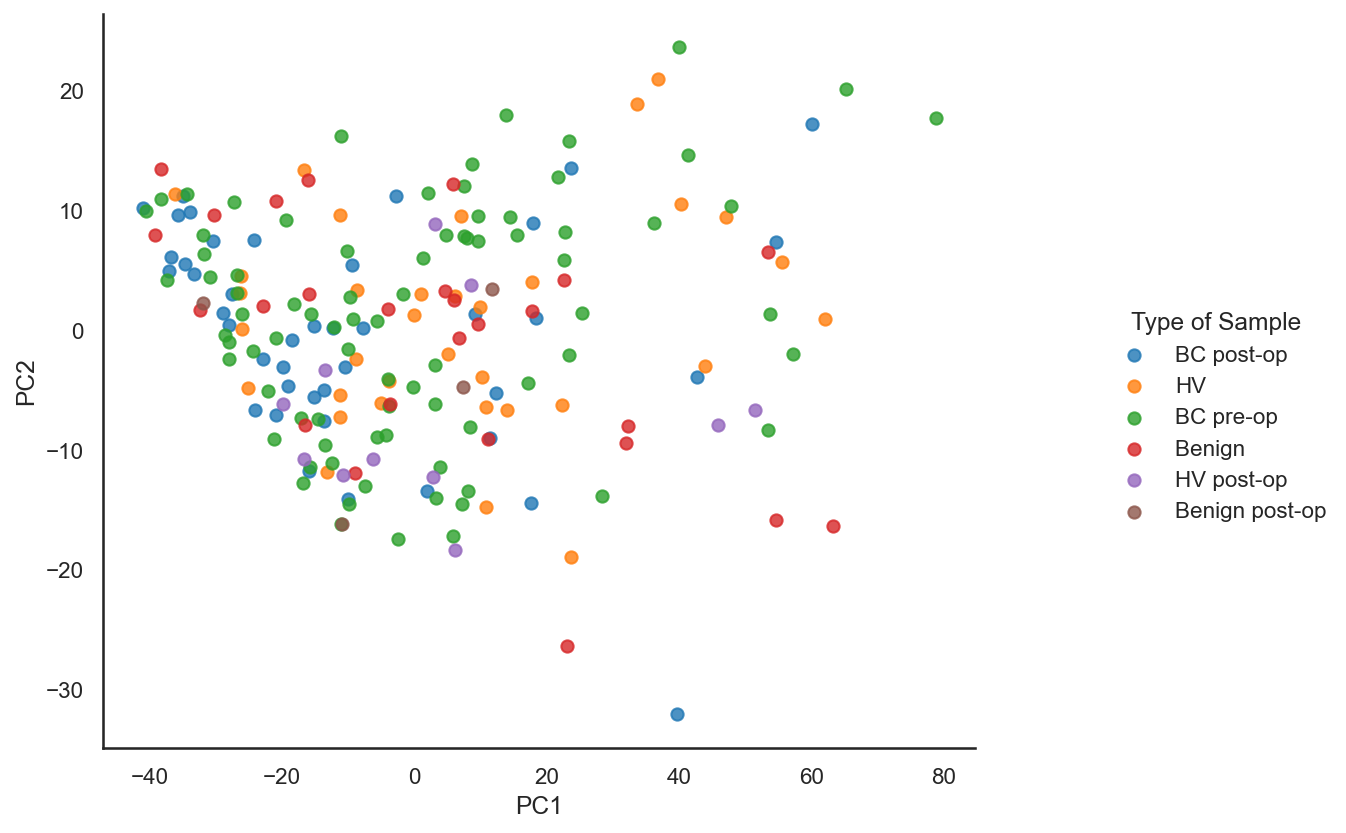

In [178]:
# PCA
sns.set_context("notebook")
sns.set_style("white")
from sklearn.decomposition import PCA
pca = PCA(n_components=5) #keep first 5 components
X_2D = pca.fit(Data_imputed).transform(Data_imputed)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2','PC3','PC4','PC5'])

# label,y= np.unique(file['Label'],return_inverse = True)
# label=file['Label']
colors = ['green','red']
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo']
# lw = 1

# PCA_data=tmp_train_r.copy()
PCA_data=pd.concat([metadata,Data_imputed],axis=1)
PCA_data['PC1'] = X_2D[:,0]
PCA_data['PC2'] = X_2D[:,1]
PCA_data['PC3'] = X_2D[:,2]
PCA_data['PC4'] = X_2D[:,3]
PCA_data['PC5'] = X_2D[:,4]


# sns.lmplot(x = "PC1", y = "PC2", hue='Cell line', data=PCA_data, palette=colors,fit_reg=False)
sns.lmplot(x = "PC1", y = "PC2", hue='Type of Sample ', data=PCA_data, fit_reg=False)
fig = plt.gcf()
fig.set_size_inches(10,6)


#save it
# plt.savefig('D:/BOX/Box Sync/RA/data/IMAGING/LD_REIMS/from Vince/cambridge multiple sclerosis/for Luca/PCA_pos.eps', format='eps')

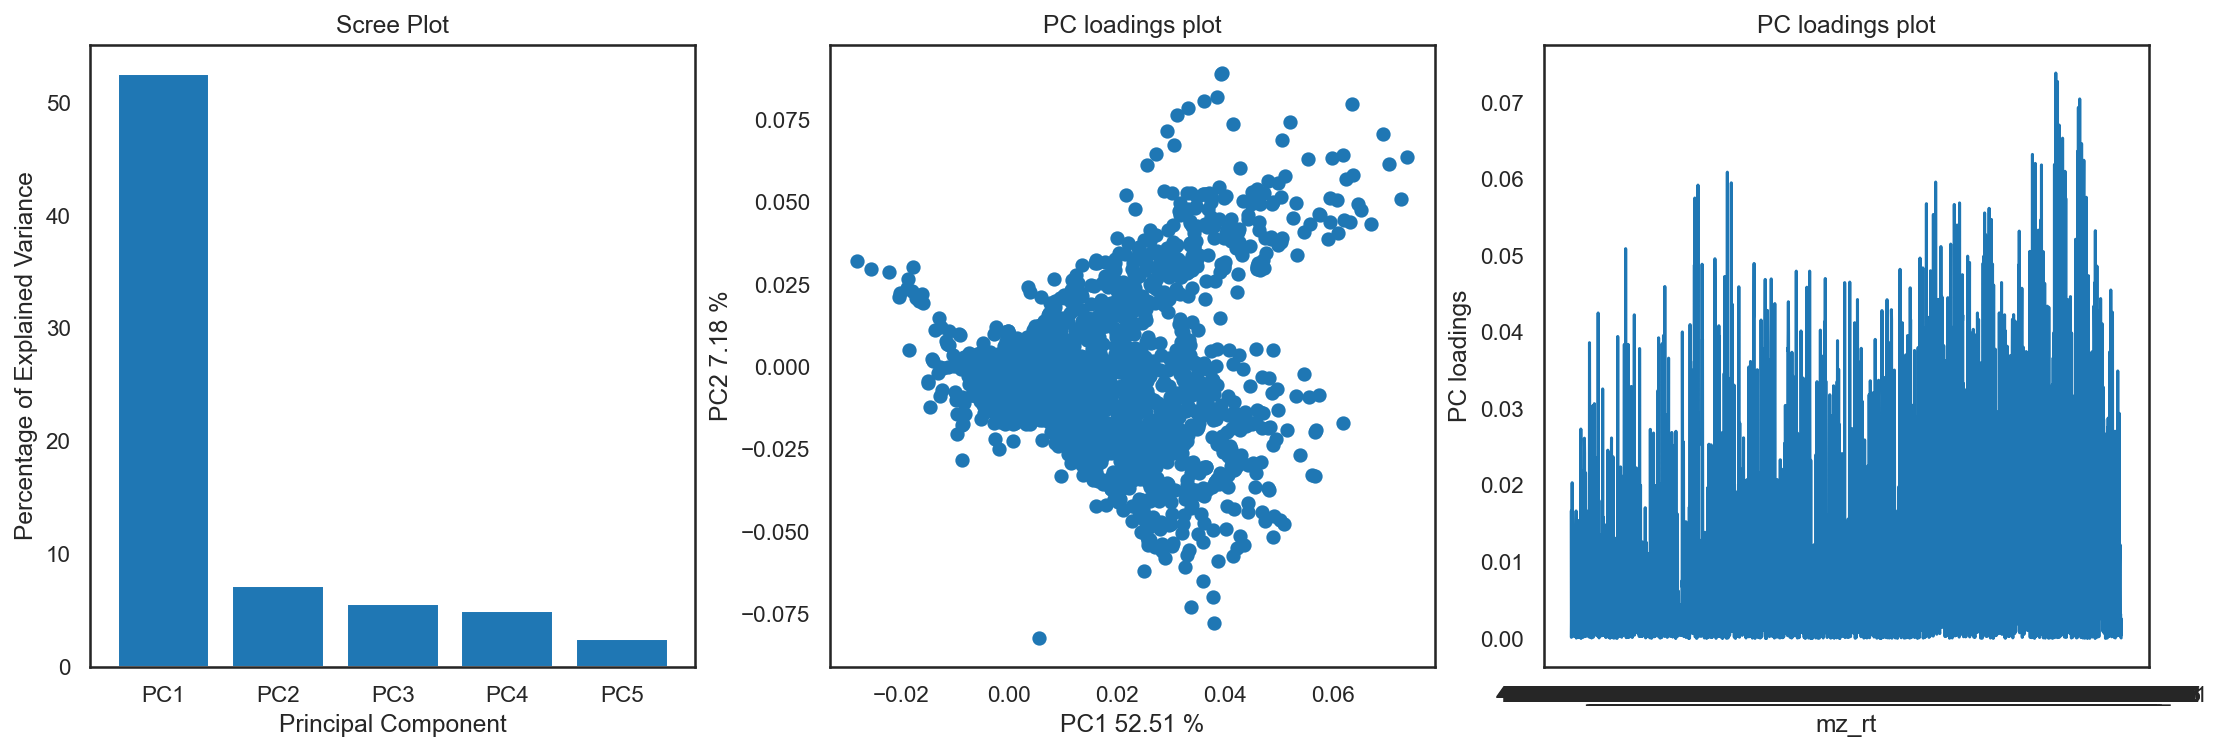

In [180]:
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

fig,axs = plt.subplots(ncols=3,constrained_layout=True,figsize=(15,5))

axs[0].bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
axs[0].set_ylabel('Percentage of Explained Variance')
axs[0].set_xlabel('Principal Component')
axs[0].set_title('Scree Plot')

axs[1].scatter(loadings['PC1'],loadings['PC2'])
axs[1].set_title('PC loadings plot')
axs[1].set_xlabel('PC1 %0.2f %%' % (pca.explained_variance_ratio_[0] * 100))
axs[1].set_ylabel('PC2 %0.2f %%' % (pca.explained_variance_ratio_[1] * 100))

axs[2].plot(tmp_train['mz_rt'],loadings['PC1'].abs())
# axs[2].plot(mz,loadings['PC3'])
axs[2].set_title('PC loadings plot')
axs[2].set_xlabel('mz_rt')
axs[2].set_ylabel('PC loadings');

In [128]:
tmp_train_r = pd.concat([metadata,Data_imputed],axis=1)

condition = ((tmp_train_r['Type of Sample '] == 'BC pre-op') | (tmp_train_r['Type of Sample '] == 'Benign ') | (tmp_train_r['Type of Sample '] == 'HV'))
tmp_train_r = tmp_train_r.loc[condition,:]
Data_train_r = tmp_train_r.iloc[:,14:]
tmp_train_r

,Sample,MS name,Type of Sample,Group,Training set,Validation set,HV and Bening Pairs,Simplified Subtype,Simplified type,Grade,...,1090.7594_7.55,1101.7723_6.08,1116.7764_7.38,1118.7914_8,1181.7606_5.28,1184.8465_2.66,1185.8053_2.98,1186.3096_12.01,1186.809_2.98,1186.8256_1.75
DORADO_LPOS_TOF18_BC_Sample_002_b.mzML,2,DORADO_LPOS_TOF18_BC_Sample_002_b.mzML,HV,HV,NaN,NaN,pair 1-a,NaN,,NaN,...,9.831,11.599,10.053,10.390,9.920,10.920,10.156,9.864,9.973,9.938
DORADO_LPOS_TOF18_BC_Sample_004_b.mzML,4,DORADO_LPOS_TOF18_BC_Sample_004_b.mzML,BC pre-op,BC pre-op,NaN,BC pre-op,NaN,ER+ HER2 Neg,ILC,1,...,10.021,11.492,9.849,10.113,9.943,10.590,10.327,9.868,10.236,10.656
DORADO_LPOS_TOF18_BC_Sample_006_b.mzML,6,DORADO_LPOS_TOF18_BC_Sample_006_b.mzML,HV,HV,NaN,NaN,NaN,NaN,NaN,NaN,...,10.035,11.474,10.095,10.325,9.993,10.410,10.354,9.857,10.163,9.970
DORADO_LPOS_TOF18_BC_Sample_008_b.mzML,8,DORADO_LPOS_TOF18_BC_Sample_008_b.mzML,BC pre-op,BC pre-op,NaN,BC pre-op,NaN,ER+ HER2 Neg,IDC,2,...,10.490,11.215,10.194,10.624,9.924,11.178,10.423,9.835,10.106,11.537
DORADO_LPOS_TOF18_BC_Sample_009_b.mzML,9,DORADO_LPOS_TOF18_BC_Sample_009_b.mzML,BC pre-op,BC pre-op,NaN,BC pre-op,NaN,ER+ HER2 Neg,IDC,2,...,10.082,11.490,10.082,10.162,10.096,11.101,10.505,9.861,10.274,10.683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DORADO_LPOS_TOF18_BC_Sample_200_b.mzML,192,DORADO_LPOS_TOF18_BC_Sample_200_b.mzML,BC pre-op,BC pre-op,NaN,BC pre-op,NaN,ER+ HER2 Neg,IDC,3,...,10.123,11.310,9.836,10.246,10.001,11.103,10.208,9.883,10.171,11.121
DORADO_LPOS_TOF18_BC_Sample_203_b.mzML,195,DORADO_LPOS_TOF18_BC_Sample_203_b.mzML,BC pre-op,BC pre-op,NaN,BC pre-op,NaN,ER+ HER2 Neg,IDC,2,...,9.893,11.057,9.905,10.188,9.866,10.594,10.317,9.866,10.162,11.555
DORADO_LPOS_TOF18_BC_Sample_204_b.mzML,196,DORADO_LPOS_TOF18_BC_Sample_204_b.mzML,BC pre-op,BC pre-op,BC pre-op,NaN,NaN,ER+ HER2 Neg,IDC,2,...,9.876,11.409,9.868,9.977,9.921,11.046,10.212,10.494,9.971,12.205
DORADO_LPOS_TOF18_BC_Sample_205_b.mzML,197,DORADO_LPOS_TOF18_BC_Sample_205_b.mzML,BC pre-op,BC pre-op,BC pre-op,NaN,NaN,ER+ HER2 Neg,IDC,3,...,9.955,10.176,10.362,10.802,10.087,12.054,9.951,9.862,9.987,9.986


## Train & CV with cost-sensitive weights

In [146]:
# get group sizes to be used for cost sensitivity if biased
column = tmp_train_r['Type of Sample ']


labelnames = set(column)
labelnames = list(labelnames)

w = np.zeros(len(labelnames))
for i in range(0,len(labelnames)):
    group=tmp_train_r[column== labelnames[i]]
#     group=file_resample[column== labelnames[i]]
    w[i]=(len(group))
    print('group' + str(i) + ' sampe size: '+str(w[i])+'\n')

# print('ratio: '+str(w/max(w)))

counts = column.value_counts().to_dict()
total = sum(counts.get(lbl, 0) for lbl in labelnames)
n_classes = len(labelnames)

class_weights = {
    lbl: total / (n_classes * counts.get(lbl, 0)) if counts.get(lbl, 0) > 0 else 0.0
    for lbl in labelnames
}
class_weights

group0 sampe size: 34.0

group1 sampe size: 26.0

group2 sampe size: 81.0



{'HV': 1.3823529411764706,
 'Benign ': 1.8076923076923077,
 'BC pre-op': 0.5802469135802469}

In [143]:
[results,model] = train_cv (Data_train_r, method='SVM', cvsplit='loo', 
                    label=column.tolist(), group=tmp_train_r['Sample'], weights = class_weights)

Method SVC(class_weight={'BC pre-op': 0.5802469135802469,
                  'Benign ': 1.8076923076923077, 'HV': 1.3823529411764706},
    decision_function_shape='ovo', kernel='linear', probability=True) iteration 0 
that took 12.601090908050537 seconds


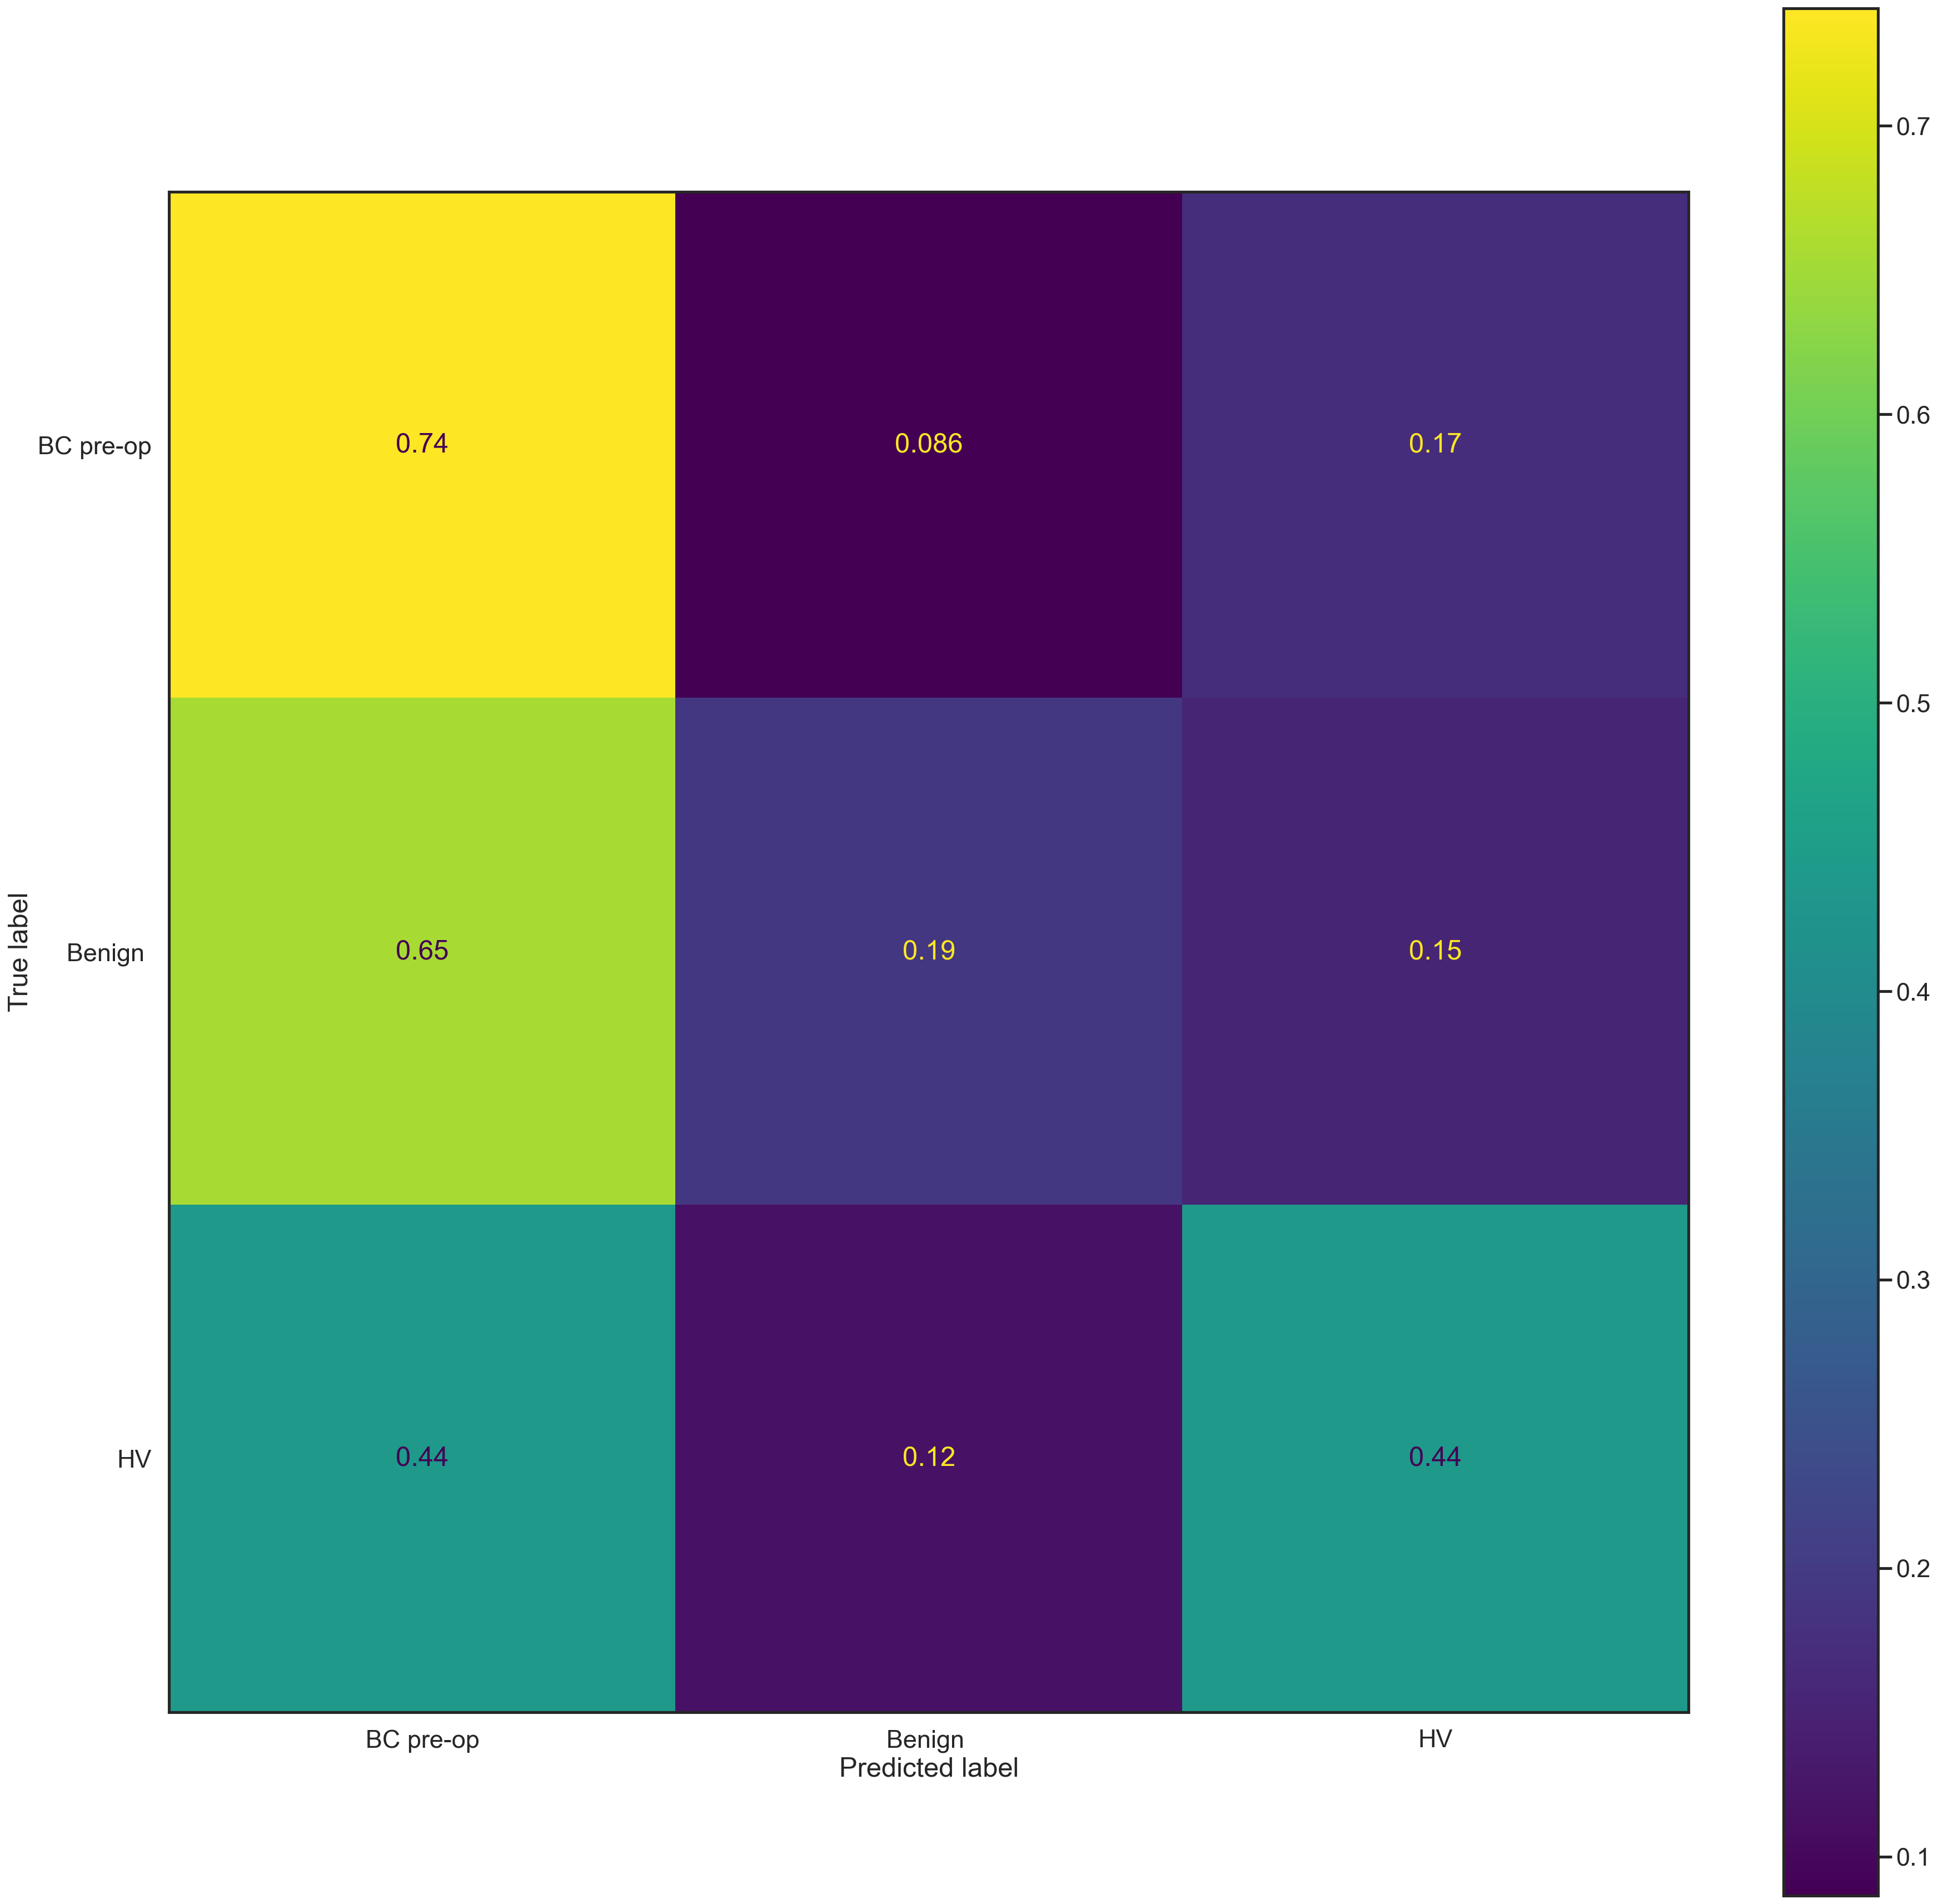

In [144]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
sns.set_style("white")
sns.set_context("poster")
classes = column

cm_label = np.unique(classes)
CM = confusion_matrix(classes, results,normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

In [170]:
# RFECV - use CV to determine & select best number of features

from sklearn.feature_selection import RFECV
print(model)

iterate = 1
RFECV_features = []
for i in range (0,iterate):
#         print(i)
    selector = RFECV(model, step=1, cv = 5, scoring = 'f1_weighted')
    selector = selector.fit(Data_train_r,tmp_train_r['Type of Sample '])
    RFECV_features.append(selector.support_)

RFECV_features = np.reshape(RFECV_features,(len(tmp_train), 1))
features_out = tmp_train['mz_rt'].iloc[RFECV_features]
features_out

SVC(class_weight={'BC pre-op': 0.5802469135802469,
                  'Benign ': 1.8076923076923077, 'HV': 1.3823529411764706},
    decision_function_shape='ovo', kernel='linear', probability=True)


354       528.2733_1.46
483       548.3351_1.68
785       596.3594_2.25
1,042     632.6338_8.28
1,133     647.4987_5.62
1,172     652.4185_1.98
1,286     669.4185_5.56
1,343     678.4327_6.78
1,346      678.471_3.19
1,650     724.4407_1.94
1,700     732.5549_5.81
1,918     762.5303_5.29
2,207    808.7395_10.32
2,810      928.7097_7.7
Name: mz_rt, dtype: object

## Train & CV again with only significant features

In [173]:
Data_train_f = Data_train_r.iloc[:,RFECV_features]
Data_train_f

,528.2733_1.46,548.3351_1.68,596.3594_2.25,632.6338_8.28,647.4987_5.62,652.4185_1.98,669.4185_5.56,678.4327_6.78,678.471_3.19,724.4407_1.94,732.5549_5.81,762.5303_5.29,808.7395_10.32,928.7097_7.7
DORADO_LPOS_TOF18_BC_Sample_002_b.mzML,9.920,12.427,10.281,12.614,11.477,13.147,10.879,11.805,12.940,12.697,14.692,9.996,10.700,10.928
DORADO_LPOS_TOF18_BC_Sample_004_b.mzML,10.330,10.633,10.640,11.650,10.266,10.551,10.719,11.791,10.844,10.609,13.291,10.277,10.612,9.873
DORADO_LPOS_TOF18_BC_Sample_006_b.mzML,10.503,10.969,11.053,12.007,10.877,11.513,13.154,11.852,11.608,12.034,13.472,10.343,10.520,10.744
DORADO_LPOS_TOF18_BC_Sample_008_b.mzML,9.909,10.621,11.969,12.447,10.925,11.877,10.484,11.817,12.416,12.448,14.300,10.562,10.647,11.118
DORADO_LPOS_TOF18_BC_Sample_009_b.mzML,10.041,10.014,9.851,11.052,9.813,9.961,12.134,12.140,9.828,9.786,13.045,10.369,12.134,10.056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DORADO_LPOS_TOF18_BC_Sample_200_b.mzML,9.862,10.544,11.148,11.868,12.410,11.908,9.867,11.813,12.162,11.885,13.568,10.005,10.796,10.349
DORADO_LPOS_TOF18_BC_Sample_203_b.mzML,10.469,10.821,10.876,11.794,10.197,10.913,10.815,11.732,11.470,11.230,14.056,10.303,10.465,10.575
DORADO_LPOS_TOF18_BC_Sample_204_b.mzML,10.432,11.233,11.172,12.317,11.787,11.144,10.501,11.978,12.120,11.373,13.898,10.242,10.601,11.297
DORADO_LPOS_TOF18_BC_Sample_205_b.mzML,10.489,12.981,11.508,13.938,13.299,14.415,10.105,11.548,14.425,14.289,16.067,10.584,11.246,11.340


In [174]:
[results,model] = train_cv (Data_train_f, method='SVM', cvsplit='loo', 
                    label=column.tolist(), group=tmp_train_r['Sample'], weights = class_weights)

Method SVC(class_weight={'BC pre-op': 0.5802469135802469,
                  'Benign ': 1.8076923076923077, 'HV': 1.3823529411764706},
    decision_function_shape='ovo', kernel='linear', probability=True) iteration 0 
that took 0.8612039089202881 seconds


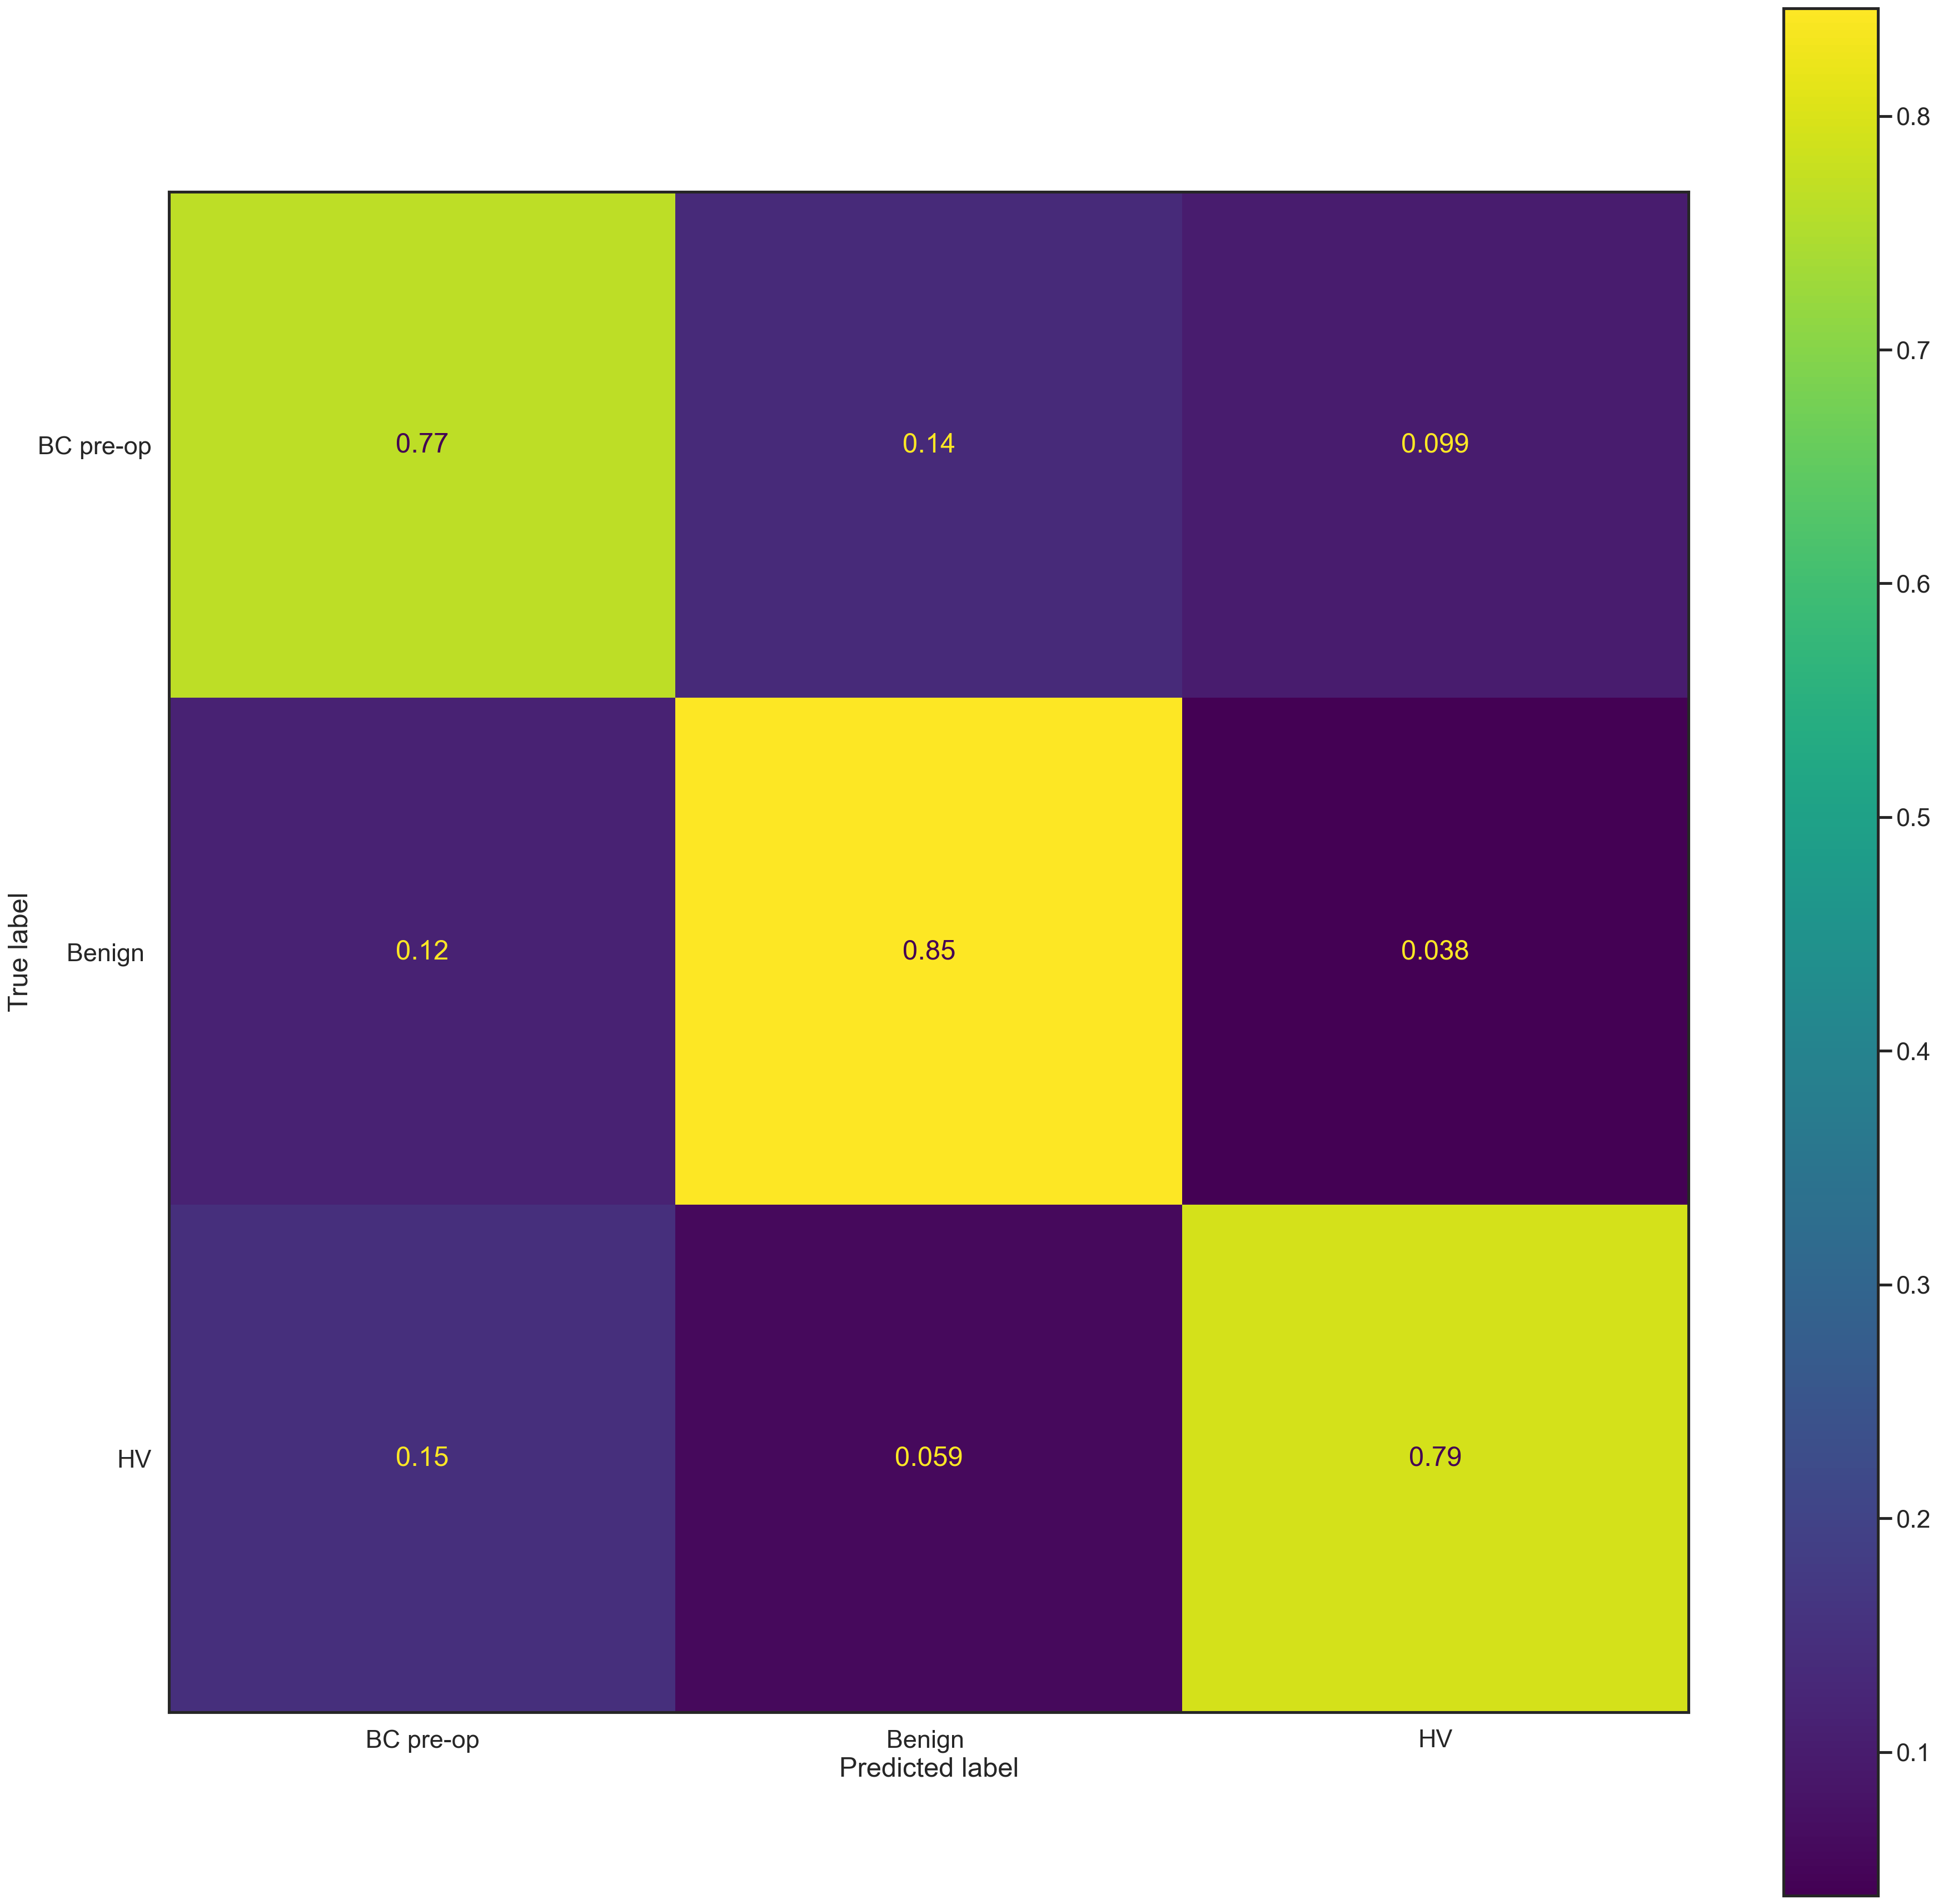

In [175]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
sns.set_style("white")
sns.set_context("poster")
classes = column

cm_label = np.unique(classes)
CM = confusion_matrix(classes, results,normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

In [181]:
performance = calculate_FPASS (CM,cm_label)
performance

,class,accuracy,sensitivity,specificity,precision,F1
0,BC pre-op,0.817,0.765,0.869,0.745,0.755
1,Benign,0.874,0.846,0.903,0.813,0.829
2,HV,0.863,0.794,0.931,0.853,0.822
3,Average,0.851,0.802,0.901,0.803,0.802


## Try on test data (all post-op)

In [190]:
tmp_test = pd.concat([metadata,Data_imputed],axis=1)

condition = ((tmp_test['Type of Sample '] == 'BC post-op') | (tmp_test['Type of Sample '] == 'Benign post-op') | (tmp_test['Type of Sample '] == 'HV post-op'))
tmp_test = tmp_test.loc[condition,:]
Data_test = tmp_test.iloc[:,14:]
Data_test = Data_test.iloc[:,RFECV_features]
tmp_test

,Sample,MS name,Type of Sample,Group,Training set,Validation set,HV and Bening Pairs,Simplified Subtype,Simplified type,Grade,...,1090.7594_7.55,1101.7723_6.08,1116.7764_7.38,1118.7914_8,1181.7606_5.28,1184.8465_2.66,1185.8053_2.98,1186.3096_12.01,1186.809_2.98,1186.8256_1.75
DORADO_LPOS_TOF18_BC_Sample_001_b.mzML,1,DORADO_LPOS_TOF18_BC_Sample_001_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,ILC,2,...,9.787,11.676,9.809,9.804,10.192,11.030,10.511,9.977,10.260,12.227
DORADO_LPOS_TOF18_BC_Sample_003_b.mzML,3,DORADO_LPOS_TOF18_BC_Sample_003_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,ILC,2,...,9.897,11.320,10.135,10.695,9.941,11.797,10.406,9.801,10.114,11.977
DORADO_LPOS_TOF18_BC_Sample_005_b.mzML,5,DORADO_LPOS_TOF18_BC_Sample_005_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,IDC,2,...,9.788,11.558,9.789,9.819,10.124,11.369,10.498,9.876,10.334,10.069
DORADO_LPOS_TOF18_BC_Sample_007_b.mzML,7,DORADO_LPOS_TOF18_BC_Sample_007_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,IDC,2,...,9.880,11.464,9.845,10.065,10.156,12.353,10.290,9.860,10.236,10.570
DORADO_LPOS_TOF18_BC_Sample_012_b.mzML,12,DORADO_LPOS_TOF18_BC_Sample_012_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,Mix,2,...,9.859,11.355,9.857,10.306,10.006,12.327,10.454,9.883,10.239,9.924
DORADO_LPOS_TOF18_BC_Sample_014_b.mzML,14,DORADO_LPOS_TOF18_BC_Sample_014_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,IDC,2,...,9.861,11.205,9.892,9.957,10.031,11.811,10.341,9.837,10.280,11.735
DORADO_LPOS_TOF18_BC_Sample_015_b.mzML,15,DORADO_LPOS_TOF18_BC_Sample_015_b.mzML,HV post-op,HV,NaN,NaN,pair 3-b,NaN,NaN,NaN,...,9.971,11.712,9.858,10.370,10.097,10.667,10.406,9.847,10.297,11.146
DORADO_LPOS_TOF18_BC_Sample_016_b.mzML,16,DORADO_LPOS_TOF18_BC_Sample_016_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,IDC,3,...,9.792,11.465,9.804,9.819,10.030,12.041,10.250,9.819,10.220,10.675
DORADO_LPOS_TOF18_BC_Sample_018_b.mzML,18,DORADO_LPOS_TOF18_BC_Sample_018_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,IDC,2,...,10.878,11.401,10.112,10.436,9.888,11.149,10.033,10.144,9.976,9.844
DORADO_LPOS_TOF18_BC_Sample_020_b.mzML,20,DORADO_LPOS_TOF18_BC_Sample_020_b.mzML,BC post-op,BC post-op,BC post-op,NaN,NaN,ER+ HER2 Neg,IDC,3,...,9.840,11.334,9.889,10.275,10.027,9.970,10.477,10.166,10.330,9.961


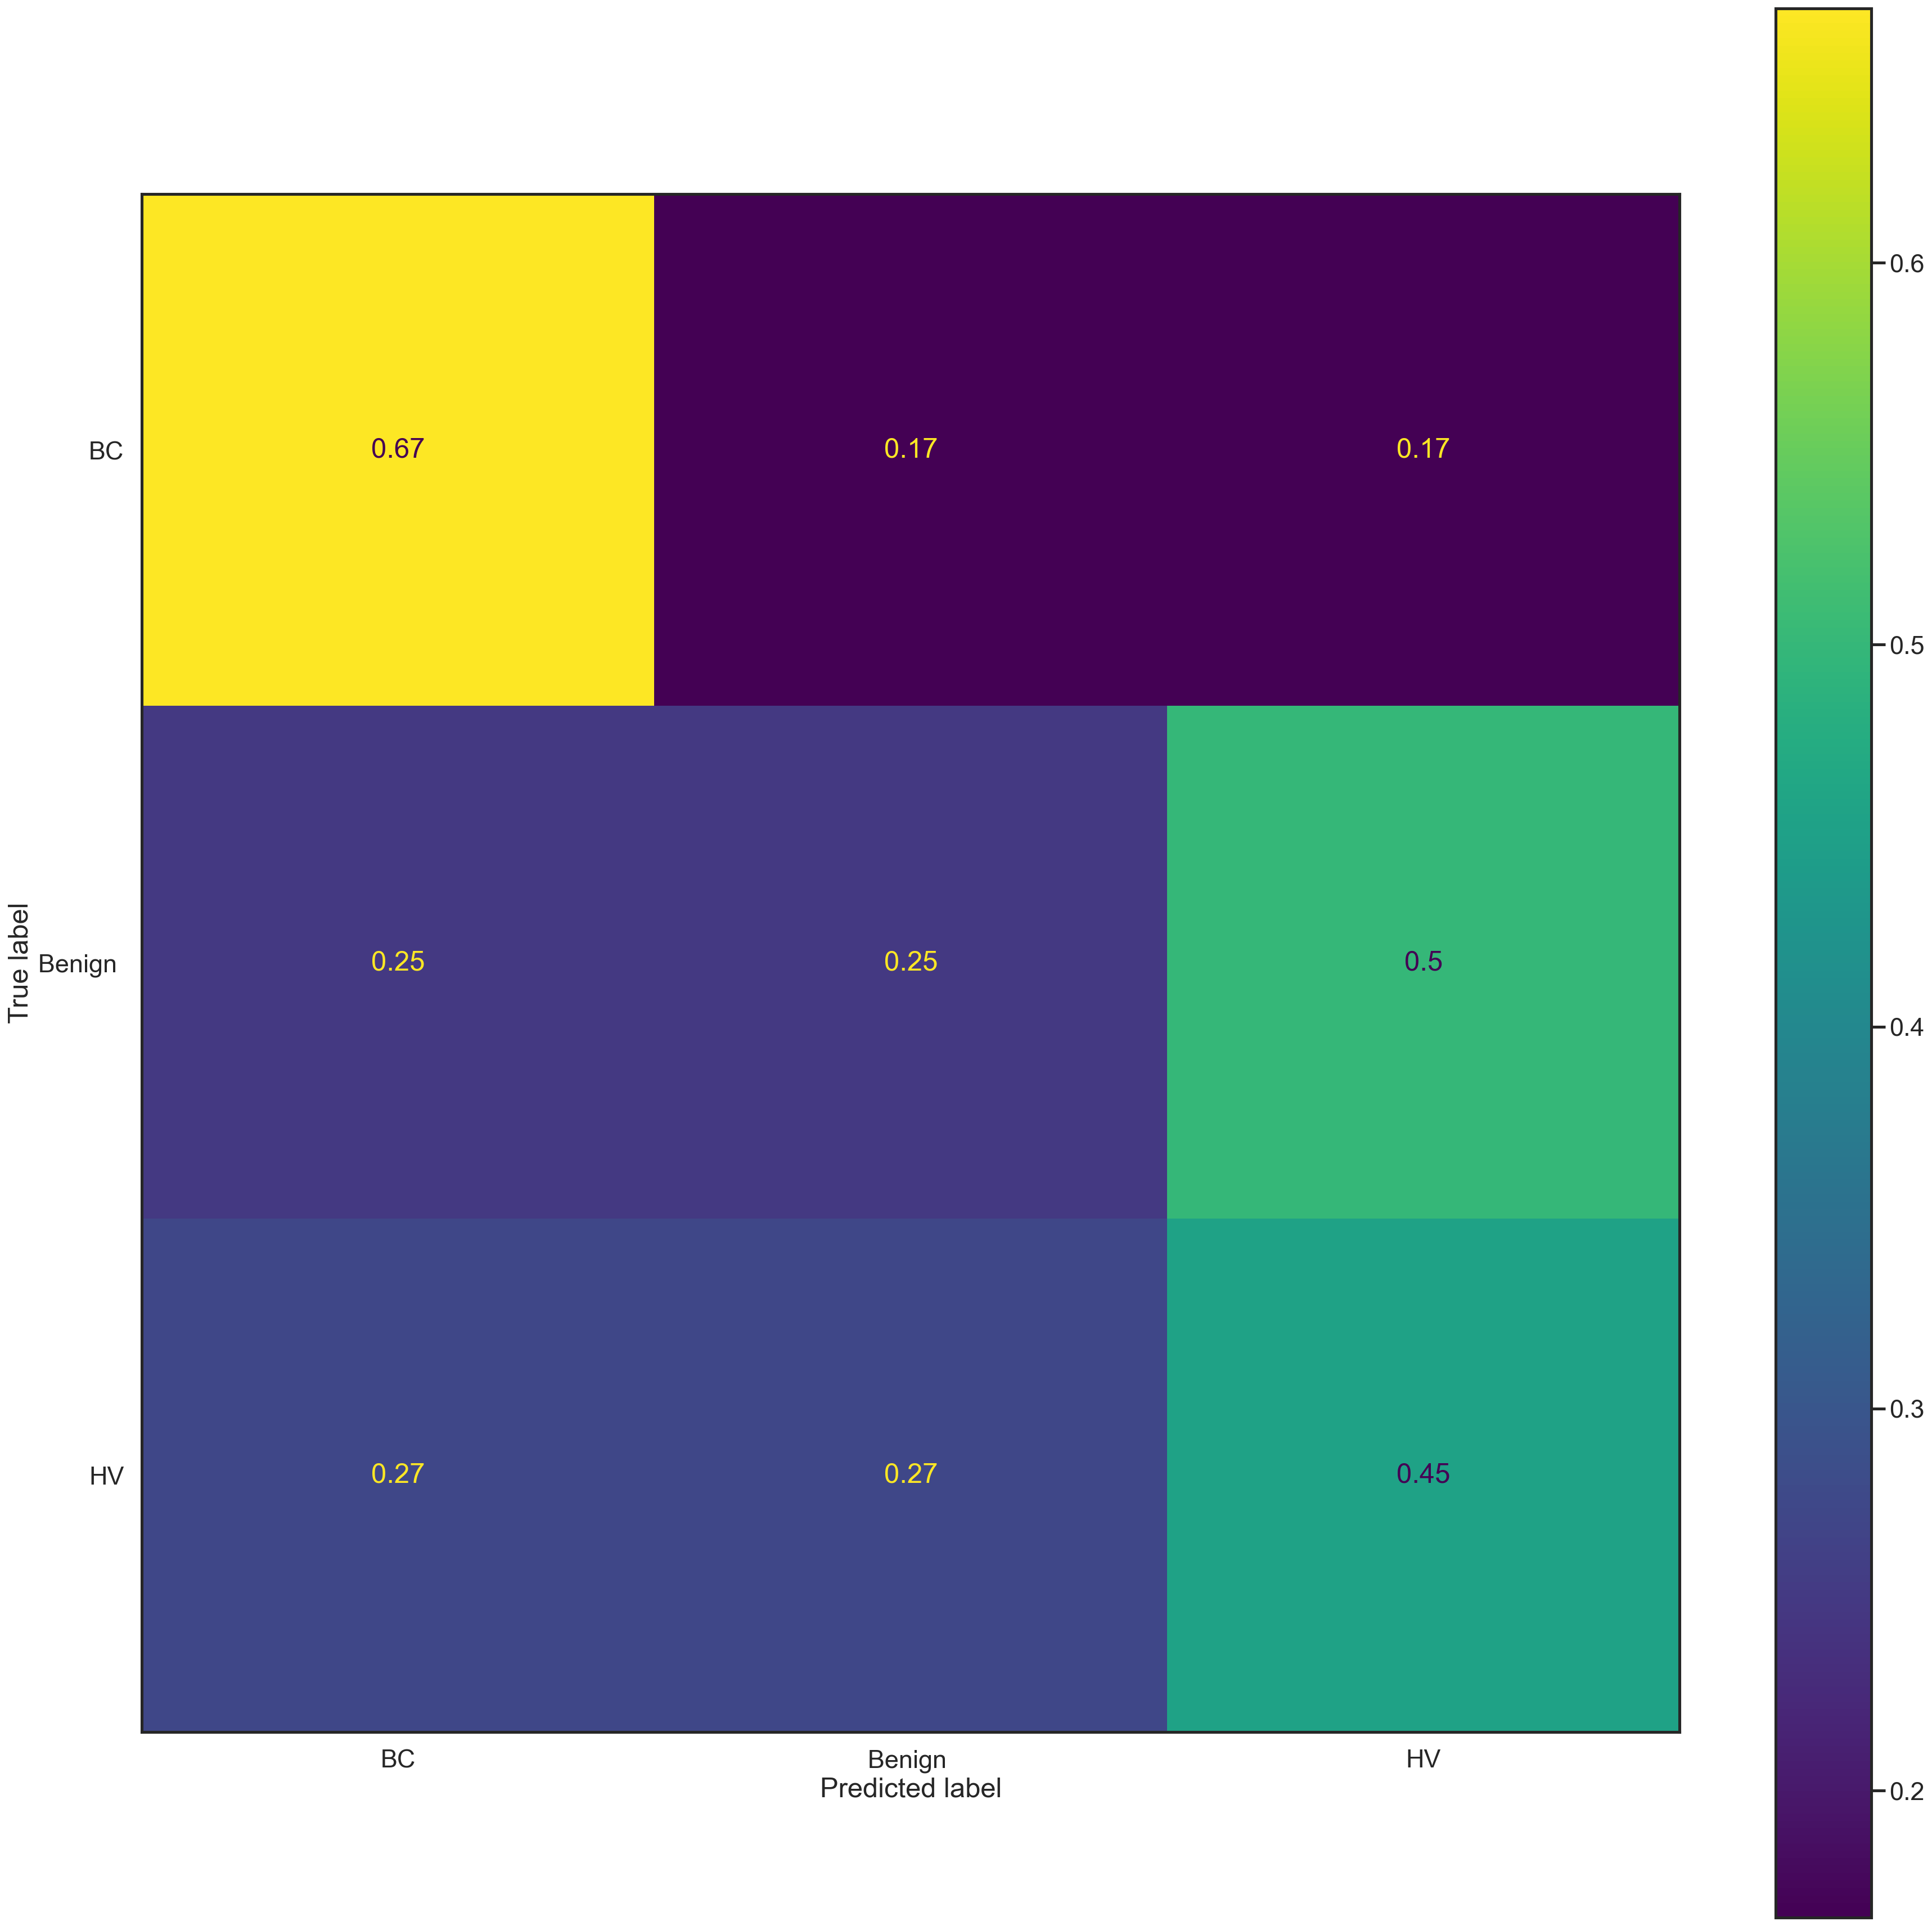

In [202]:
model_to_use = model.fit(Data_train_f, column.tolist())
classes = tmp_test['Type of Sample '].tolist()
test_results = model_to_use.predict(Data_test)

classes = [w.replace('BC post-op', 'BC') for w in classes]
classes = [w.replace('Benign post-op', 'Benign ') for w in classes]
classes = [w.replace('HV post-op', 'HV') for w in classes]
test_results = [w.replace('BC pre-op', 'BC') for w in test_results]
CM = confusion_matrix(classes, test_results, normalize='true')
cm_label = np.unique(classes)

sns.set_context("poster")
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

In [207]:
box_plot(features_out, features, tmp_test,'Type of Sample ', save=True, savepath = 'C:/Users/LocalAdmin/Box/Publications/collabs/Erika/OneDrive_1_24-07-2026/',lcdata = True)

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_42008\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_42008\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


plot for 528.2733_1.46 saved.
plot for 548.3351_1.68 saved.


C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_42008\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_42008\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


plot for 596.3594_2.25 saved.
plot for 632.6338_8.28 saved.


C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_42008\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_42008\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


...

plot for 678.471_3.19 saved.
plot for 724.4407_1.94 saved.


C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_42008\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_42008\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


plot for 732.5549_5.81 saved.
plot for 762.5303_5.29 saved.


C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_42008\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_42008\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


plot for 808.7395_10.32 saved.
plot for 928.7097_7.7 saved.
